---
title: "Matrix completion CV results on PGC (NNM-Corr)"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-02"
file-modified: "2026-06-02"
abstract: "This notebook shows the results of matrix completion CV on PGC using NNM-Corr model and PGD-AFW solver."
---

## Background

Matrix completion cross-validation (CVMC) on the PGC data using NNM model showed a monotonically decreasing prediction error on the heldout matrix elements with increasing nuclear norm constraint. We assumed that this is because the 107 PGC psychiatric traits are strongly correlated with one another: virtually every masked entry is predictable from neighboring traits regardless of the nuclear norm constraint, so prediction error keeps falling as we increase $r$. With the split replication cross-validation (CVSR), we observed that the NNM-Corr model shows a wide range of nuclear norm constraints, at which relative spectral gap remains substantially high for many $k$ values. However, the projection distance between subspaces were noisy.

The distinct difference in the spectral behavior of NNM and NNM-Corr models made me rethink the failure mode in CVMC. Is it because of the model misspecification rather than a genuine "no interior optimum" property of the data? The "noise" that the NNM model "thinks" it's fitting at large $r$ is actually correlated signal across traits (the off-diagonal of A). The correlated signal looks like additional low-rank structure, so larger r keeps capturing more of it without ever overfitting — bias decreases, the model's notion of variance stays low, and held-out MSE keeps coming down. There's no interior optimum because the model never reaches its misspecified noise floor.

Therefore, before giving up on the CVMC, I wanted to check the behavior with the NNM-Corr model. With the correct noise model, shrinkage could give a real bias-variance trade-off and the curve could bend back up at large $r$. Moreover, the heldout MSE is measured in the Frobenius metric, which is what the sampling covariance would be whitening against. Even if there were an interior optimum in the correct (Mahalanobis) loss, we wouldn't see it in plain Frobenius MSE.

## Configuration

In [2]:
import re
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Input files

In [3]:
data_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis/clorinn/cv_matrix_completion"
prefix = "pgd_afw_nnm_corr"
metrics_out_dir = Path(data_root) / "fit_metrics"
fit_result_out_dir = Path(data_root) / "fit_result"
cv_input_path = Path(data_root) / "cv_input/heldout_assignments.npz"
zscore_path = Path("/gpfs/commons/groups/knowles_lab/data/PsychGen/input/pgc_v1.0/zscore_v1_0.csv")
noise_cov_path = Path("/gpfs/commons/groups/knowles_lab/data/PsychGen/input/pgc_v1.0/sampling_covariance_v1_0.csv")

## Functions

In [4]:
def load_metrics_jsons(metrics_dir, prefix):
    metrics_dir = Path(metrics_dir)
    paths = sorted(metrics_dir.glob(f"{prefix}_r*.json"))

    records = []
    for path in paths:
        with open(path) as fh:
            rec = json.load(fh)
        records.append(rec)

    return records

def build_metrics_df(records, name="heldout_rmse"):
    rows = []
    for record in records:
        for rec in record:
            rows.append({
                "fold_id": int(rec["fold_id"]),
                name: float(rec[name]),
                "nucnorm": int(round(float(rec["nucnorm"]))),
            })
    return pd.DataFrame(rows)

def get_r_scaled(x, scale="log2"):
    x = np.asarray(x, dtype=float)
    powers = np.arange(np.ceil(np.log2(x.min())), np.floor(np.log2(x.max())) + 1)
    xlabels = 2 ** powers
    
    if scale == "log10":
        xscale = np.log10(x)
        xticks = np.log10(xlabels)
    elif scale == "log2":
        xscale = np.log2(x)
        xticks = np.log2(xlabels)
    else:
        xscale = x
        xticks = xlabels

    return xscale, xticks, xlabels

def heldout_mahalanobis_metrics(ztrue, zhat, zmask, noise_cov):
    
    from clorinn.optimize.objectives import NNMCorrObjective

    zmask = np.asarray(zmask).astype(bool)
    scored = zmask & np.isfinite(ztrue)
    n_heldout = int(np.count_nonzero(scored))
    if n_heldout == 0:
        raise ValueError("zmask does not contain any held-out entries.")

    score_obj = NNMCorrObjective(
        Y         = ztrue,
        radius    = 1.0,
        noise_cov = noise_cov,
        mask      = ~zmask,
    )

    half_sum    = float(score_obj.value(zhat))   # 0.5 * sum_i q_i
    mahal_sum   = 2.0 * half_sum                  # sum_i q_i
    mahal_mean  = mahal_sum / n_heldout

    return mahal_mean

def get_mahalanobis_error_from_simulations(
    fit_result_out_dir, prefix, zscore_path, noise_cov_path, cv_input_path, r_target=None
):
    import sys
    sys.path.append("/gpfs/commons/home/sbanerjee/work/npd/psychgen/workflow/scripts")
    from helpers import load_zscore_and_noise
    from cv_mc_fit_clorinn_common import load_matrix_completion_input
    
    from clorinn.utils import SamplingCovariance
    
    model = "nnm-corr"
    repeat_id = 0 # only single repeat in simulations
    if r_target is None:
        paths = sorted(fit_result_out_dir.glob(f"{prefix}_r*.pkl"))
    else:
        paths = sorted(fit_result_out_dir.glob(f"{prefix}_r{r_target}*.pkl"))
    
    assignments, observed_indices, fold_sizes, n_folds, n_repeats = load_matrix_completion_input(cv_input_path)
    Z, noise_cov = load_zscore_and_noise(
        zscore_path,
        noise_cov_path = noise_cov_path,
        model = model
    )
    noise_cov = SamplingCovariance.from_matrix(noise_cov)
    N, P = Z.shape
    
    rows = []
    for path in paths:
        with open(path, 'rb') as f:
            fit_results = pickle.load(f)

        for fold_id in range(n_folds):
            held_idx = observed_indices[assignments[repeat_id] == fold_id]
            mask = np.zeros(Z.shape, dtype=bool)
            mask.flat[held_idx] = True
            fit_result = fit_results[fold_id]['final_result']
            nucnorm = fit_result.metrics["radius"]
            mahalanobis_mse = heldout_mahalanobis_metrics(Z, fit_result.X, mask, noise_cov)
            rows.append({
                "fold_id": fold_id,
                "mahalanobis_mse": mahalanobis_mse,
                "nucnorm": int(round(nucnorm)),
            })
            
        print (f"Loaded data for nucnorm={nucnorm}")
    return pd.DataFrame(rows)

## Mahalanobis loss

The CVMC pipeline, in its current implementation, does not report the Mahalanobis loss on the heldout entries. Hence, we have to calculate it post-hoc. Since this is time-consuming, we save the dataframe for future reproduction. 



In [5]:
# corr_mse_long_df = get_mahalanobis_error_from_simulations(
#     fit_result_out_dir, prefix, zscore_path, noise_cov_path, cv_input_path)

# corr_mse_long_df.to_csv("cvmc_mahalanobis_mse_all_folds.csv")
corr_mse_long_df = pd.read_csv("cvmc_mahalanobis_mse_all_folds.csv", index_col=0)

In [6]:
def get_summary_df(long_df, metric_name):
    df = (long_df
            .groupby(["nucnorm"], as_index=False)
            .agg(
                value = (metric_name, "mean"),
                sd=(metric_name, "std"),
                n=(metric_name, "count"),
            )
            .assign(
            se=lambda x: x["sd"] / np.sqrt(x["n"]),
            var_coef=lambda x: 100.0 * x["sd"] / x["value"],
            )
            .sort_values(["nucnorm"])
         )
    return df

metric_name = "heldout_mse"
mse_records = load_metrics_jsons(metrics_out_dir, prefix)
long_df = build_metrics_df(mse_records, name=metric_name)
mse_df = get_summary_df(long_df, metric_name)
corr_mse_df = get_summary_df(corr_mse_long_df, "mahalanobis_mse")

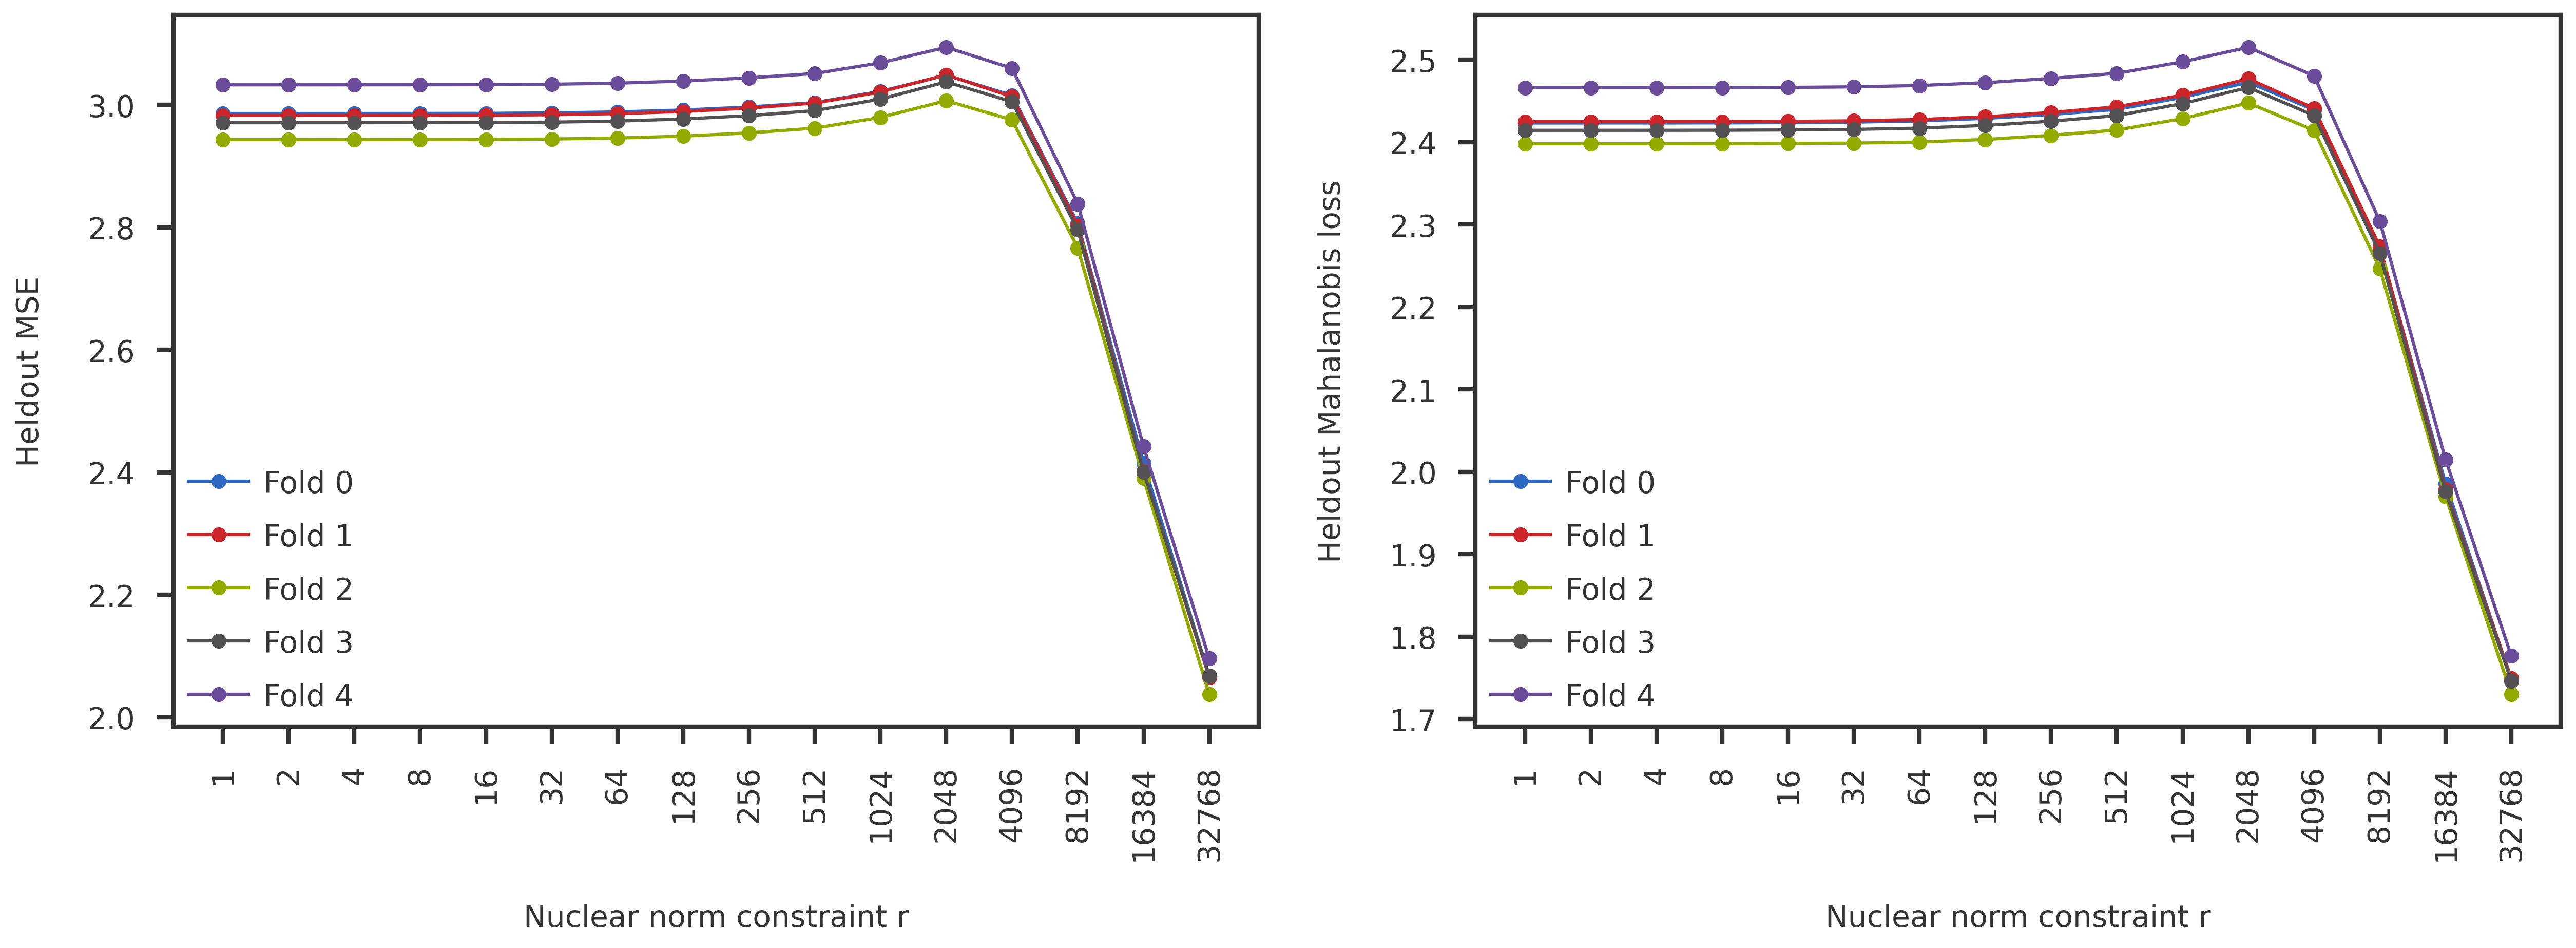

In [7]:
fig = plt.figure(figsize=(20,6))
gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.2, hspace=0)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

rank_list = mse_df["nucnorm"].to_numpy()
r, rticks, rlabels = get_r_scaled(rank_list, scale='log2')

for fold_id in range(5):
    df = long_df[long_df["fold_id"] == fold_id].sort_values(["nucnorm"])
    y  = df[metric_name].to_numpy()
    ax1.plot(r, y, 'o-', label=f"Fold {fold_id}")
    
    df = corr_mse_long_df[corr_mse_long_df["fold_id"] == fold_id].sort_values(["nucnorm"])
    y  = df["mahalanobis_mse"].to_numpy()
    ax2.plot(r, y, 'o-', label=f"Fold {fold_id}")
    
ax1.set_ylabel("Heldout MSE")
ax2.set_ylabel("Heldout Mahalanobis loss")

for ax in [ax1, ax2]:
    ax.legend(handlelength=2)
    ax.set_xticks(rticks)
    ax.set_xticklabels([str(int(r)) for r in rlabels], rotation=90)
    ax.set_xlabel("Nuclear norm constraint r")
    

plt.show()

## Inter-fold dispersion

The heldout MSE and Mahalanobis loss are very similar, and neither show any crossover in the prediction error. One last thing to check would be the inter-fold dispersion: Is there any difference between the coefficient of variation (`std / mean`) between the different folds used in the CVMC? 

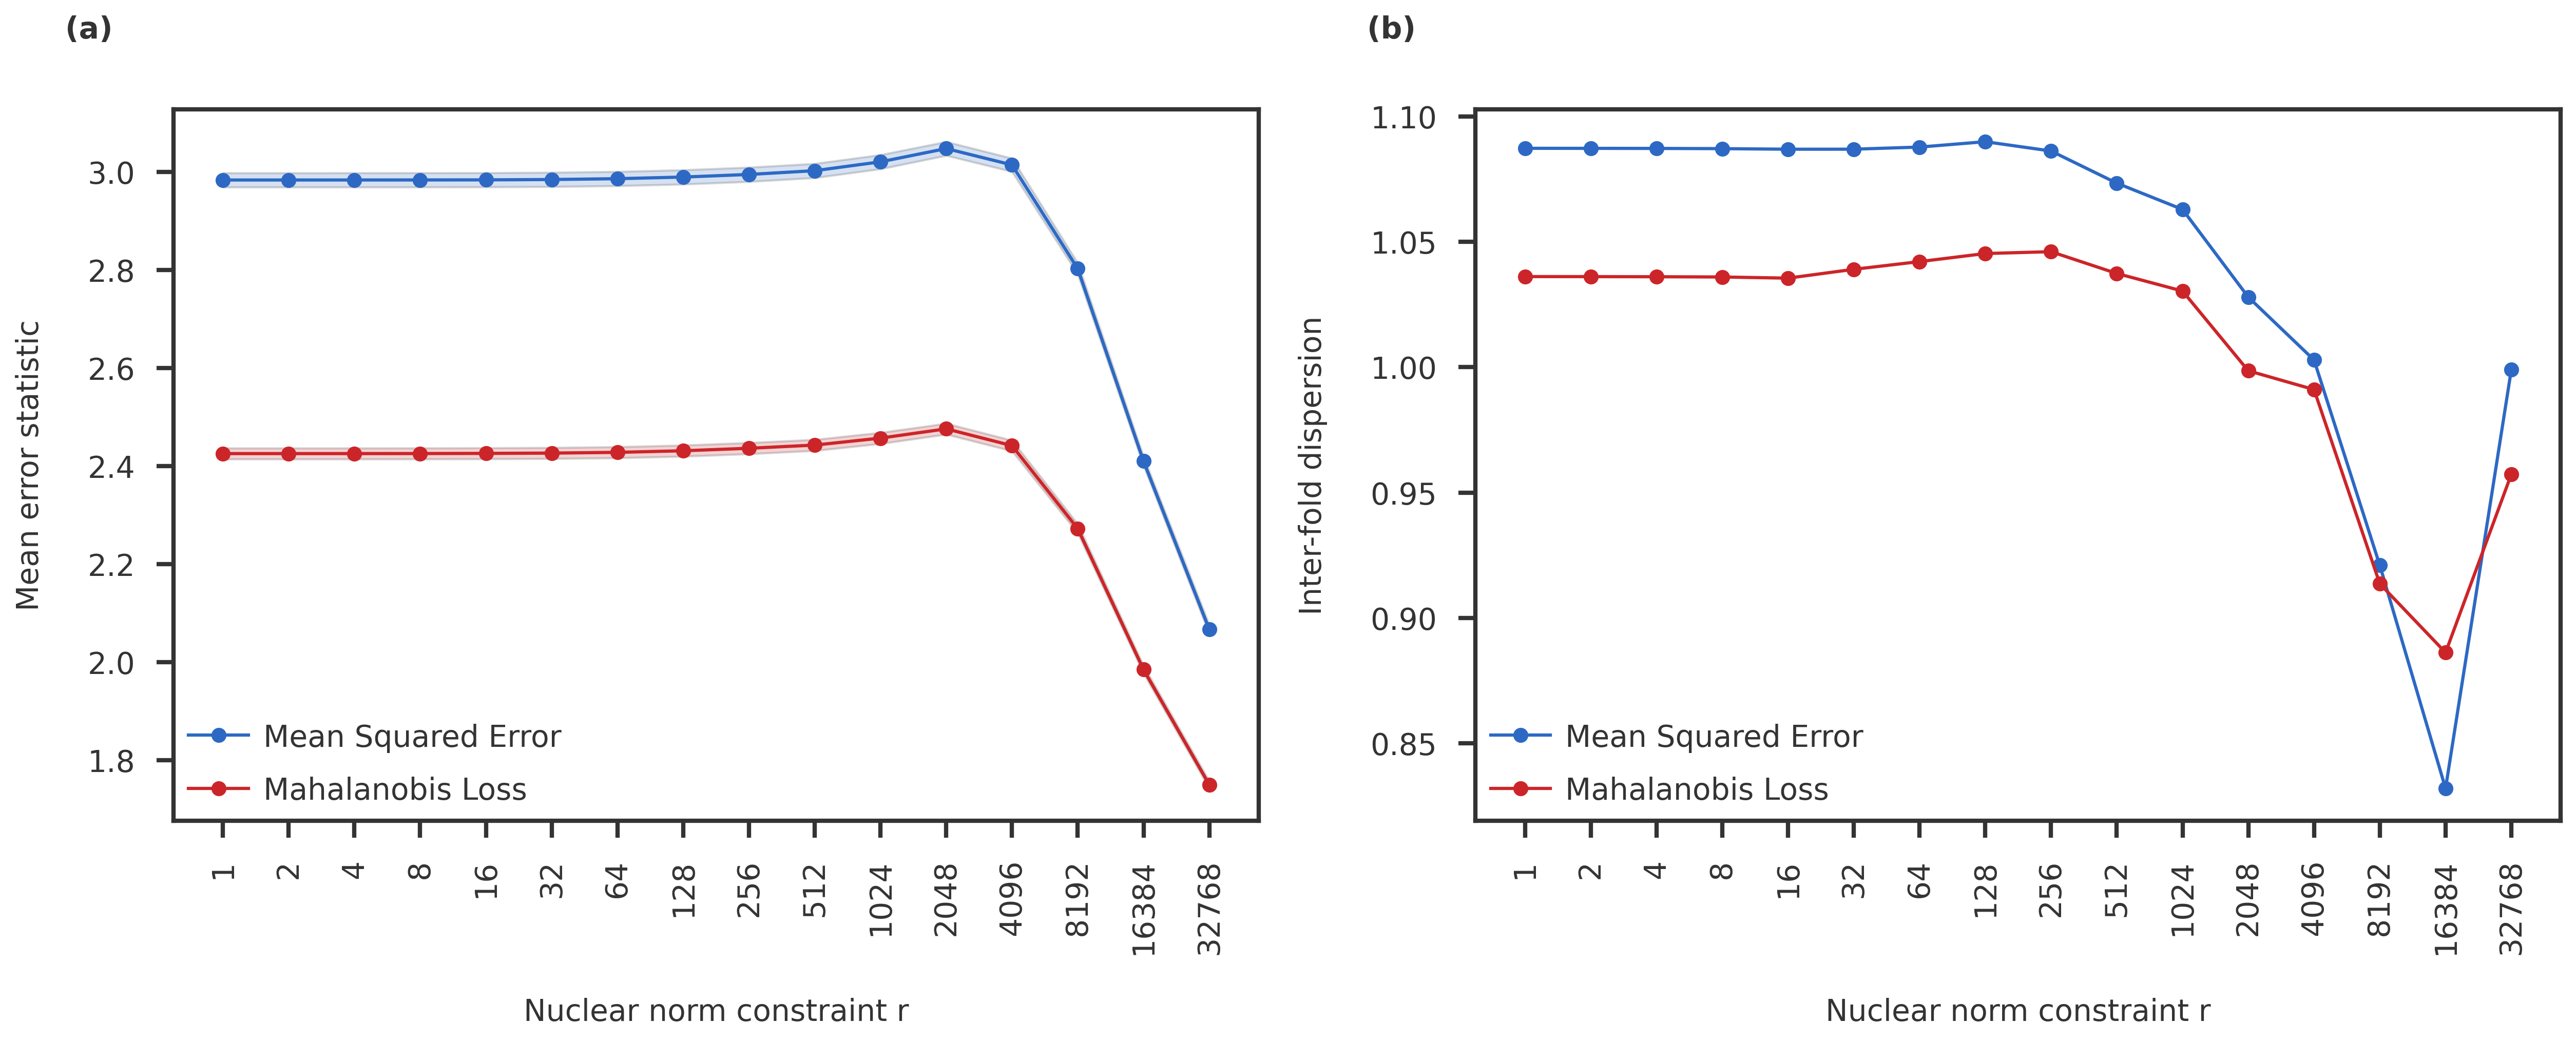

In [8]:
fig = plt.figure(figsize=(20,6))
gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.2, hspace=0)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

rank_list = mse_df["nucnorm"].to_numpy()
r, rticks, rlabels = get_r_scaled(rank_list, scale='log2')

y1  = mse_df["value"].to_numpy()
se1 = mse_df["se"].to_numpy()
ax1.plot(r, y1, 'o-', label="Mean Squared Error")
ax1.fill_between(r, y1+se1, y1-se1, alpha=0.2)

y2  = corr_mse_df["value"].to_numpy()
se2 = corr_mse_df["se"].to_numpy()
ax1.plot(r, y2, 'o-', label="Mahalanobis Loss")
ax1.fill_between(r, y2+se2, y2-se2, alpha=0.2)

ax1.set_ylabel("Mean error statistic")

cv1 = mse_df["var_coef"].to_numpy()
cv2 = corr_mse_df["var_coef"].to_numpy()
ax2.plot(r, cv1, 'o-', label="Mean Squared Error")
ax2.plot(r, cv2, 'o-', label="Mahalanobis Loss")

ax2.set_ylabel("Inter-fold dispersion")

for ax in [ax1, ax2]:
    ax.legend(handlelength=2)
    ax.set_xticks(rticks)
    ax.set_xticklabels([str(int(r)) for r in rlabels], rotation=90)
    ax.set_xlabel("Nuclear norm constraint r")

for label, ax in zip(["(a)", "(b)"], [ax1, ax2]):
    ax.text(-0.1, 1.1, label, transform=ax.transAxes, fontweight='bold')
    
# fig.savefig(
#         f"figures/cvmc_nnmcorr_heldout_error.pdf",
#         bbox_inches="tight",
#     )

plt.show()

## Summary

The NNM-Corr CVMC results are also monotonic and does not show any regime change with varying nuclear norm constraint for the PGC data.

Additionally, I also checked the proportion of heldout entries per disease category. The categories were manually curated by Shane. I found no discernible anomaly in the proportion of heldout entries. 